In [49]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("burnoutminer/heights-and-weights-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heights-and-weights-dataset' dataset.
Path to dataset files: /kaggle/input/heights-and-weights-dataset


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [51]:
!ls $path

SOCR-HeightWeight.csv


In [52]:
df = pd.read_csv(path+"/SOCR-HeightWeight.csv")

In [53]:
df.head()

,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971


In [54]:
df.columns

Index(['Index', 'Height(Inches)', 'Weight(Pounds)'], dtype='object')

In [55]:
df['height'] = df['Height(Inches)'] * 2.54

In [56]:
df.head()

,Index,Height(Inches),Weight(Pounds),height
0,1,65.78331,112.9925,167.089607
1,2,71.51521,136.4873,181.648633
2,3,69.39874,153.0269,176.272800
3,4,68.21660,142.3354,173.270164
4,5,67.78781,144.2971,172.181037


In [57]:
df['weight'] = df['Weight(Pounds)'] * 0.453592

In [58]:
df.head(5)

,Index,Height(Inches),Weight(Pounds),height,weight
0,1,65.78331,112.9925,167.089607,51.252494
1,2,71.51521,136.4873,181.648633,61.909547
2,3,69.39874,153.0269,176.272800,69.411778
3,4,68.21660,142.3354,173.270164,64.562199
4,5,67.78781,144.2971,172.181037,65.452010


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Index           25000 non-null  int64  
 1   Height(Inches)  25000 non-null  float64
 2   Weight(Pounds)  25000 non-null  float64
 3   height          25000 non-null  float64
 4   weight          25000 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 976.7 KB


In [60]:
df.isnull().sum()

,0
Index,0
Height(Inches),0
Weight(Pounds),0
height,0
weight,0


In [61]:
X = df[['height']]
y = df['weight']

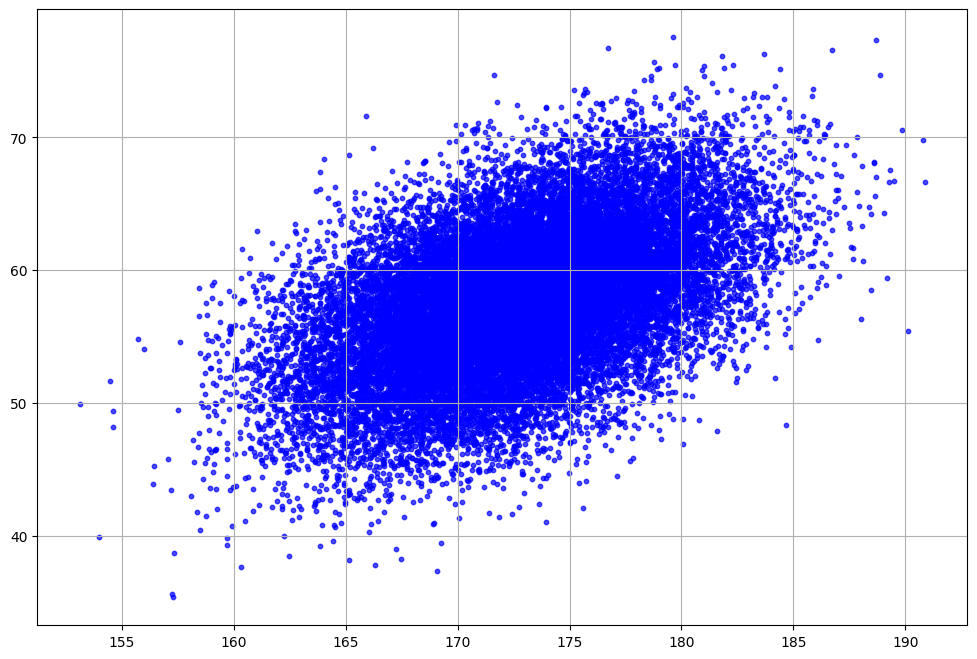

In [62]:
plt.figure(figsize=(12, 8))
plt.scatter(X, y, color='blue', alpha=0.7, s=10)
plt.grid(True)

In [63]:
from sklearn.model_selection import train_test_split

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [65]:
X_train.head()

,height
4913,171.622009
9338,178.922985
24211,172.830312
18791,169.814037
16066,174.482963


In [66]:
X_test.head()

,height
6868,173.798154
24016,172.457440
9668,171.854419
13640,175.292995
14018,175.286797


## Linear Regression

In [67]:
w = 0
b = 0
learning_rate = 0.00001
l = len(X_train)

In [68]:
def mean_squared_error(y, y_pred):
  return (y-y_pred)**2

In [69]:
X_train = X_train['height'].values
y_train = y_train.values

In [70]:
def find_derivatives(X, y, w, b):
  y_pred = w*X + b
  error = y-y_pred
  dw = -2*np.sum(error*X)/l
  db = -2*np.sum(error)/l
  return dw, db


In [71]:
X = X_train
y = y_train
w, b = 0, 0
learning_rate = 0.00000001
epochs = 200000


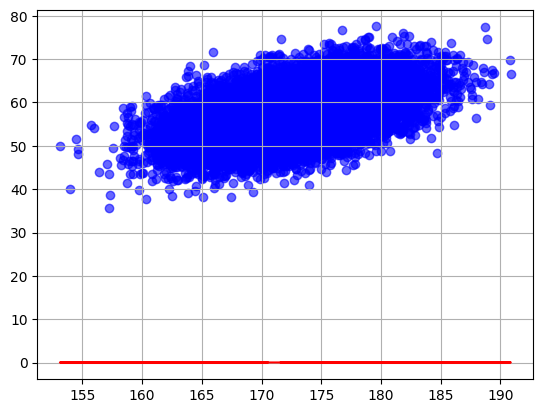

Epoch 0: Hata (MSE) = 3345.8012


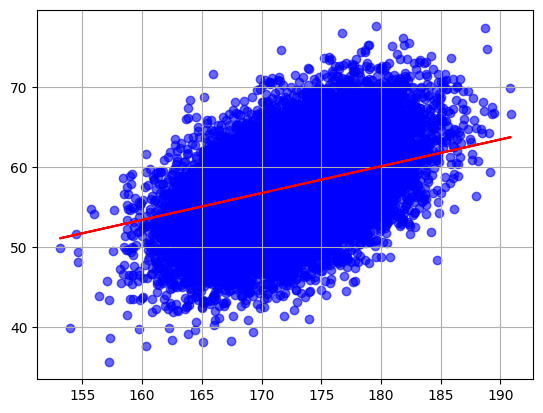

Epoch 50000: Hata (MSE) = 21.9270


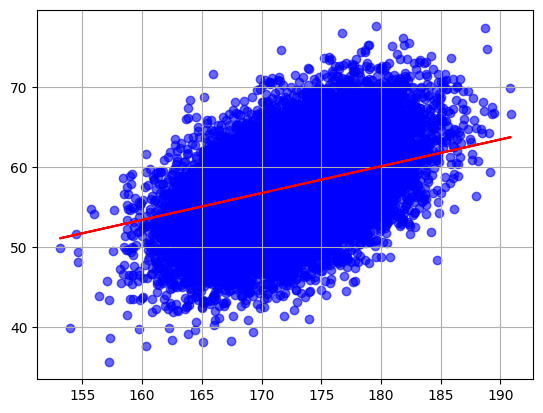

Epoch 100000: Hata (MSE) = 21.9270


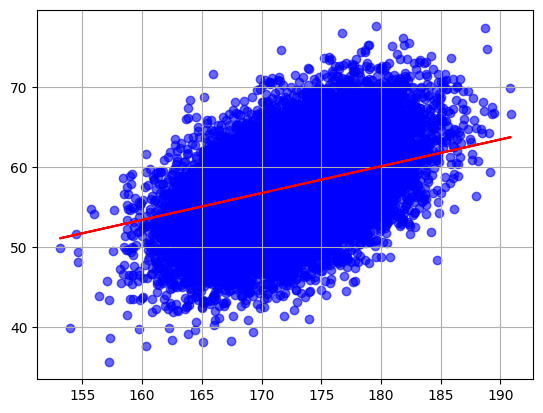

Epoch 150000: Hata (MSE) = 21.9270


In [72]:
for i in range(epochs):
  dw, db = find_derivatives(X, y, w, b)

  w = w - learning_rate * dw
  b = b - learning_rate * db

  if i%50000==0:
    y_pred = X *w+b
    mse = np.mean((y-y_pred)**2)
    plt.scatter(X, y, color='blue', alpha=0.6)
    plt.plot(X, y_pred, color='red')
    plt.grid(True)
    plt.show()
    print(f"Epoch {i}: Hata (MSE) = {mse:.4f}")


In [93]:
X = X_train
X_scaled = (X-np.mean(X))/np.std(X)
X = X_scaled
y = y_train
w, b = 0, 0
learning_rate = 0.0001
epochs = 200000



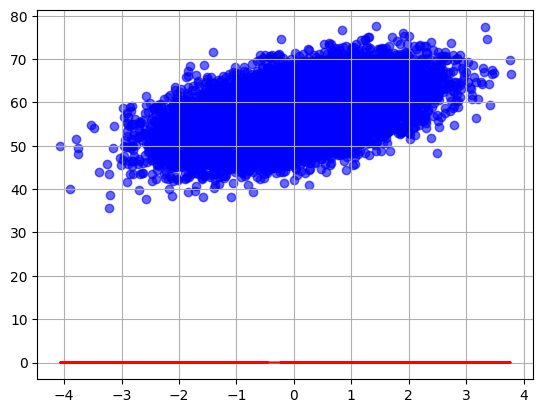

Epoch 0: Mean Squared Error (MSE) = 3348.4425125879443


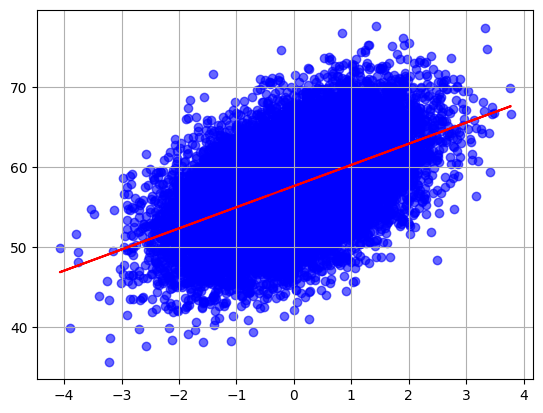

Epoch 50000: Mean Squared Error (MSE) = 20.864952821585657


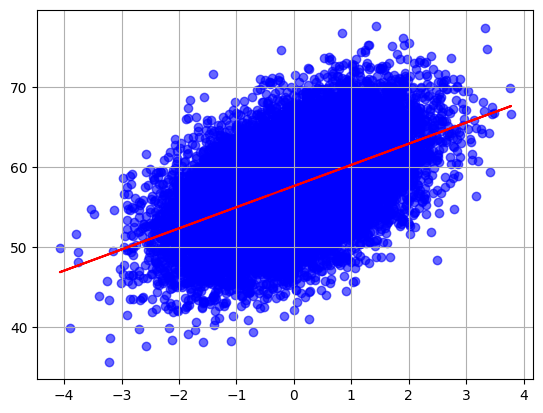

Epoch 100000: Mean Squared Error (MSE) = 20.86494597664253


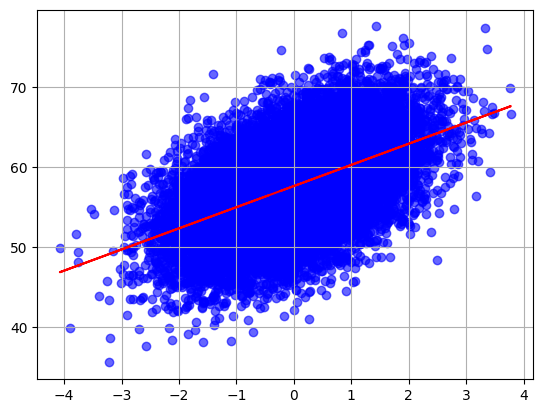

Epoch 150000: Mean Squared Error (MSE) = 20.86494597664252


In [94]:
for i in range(epochs):
  dw, db = find_derivatives(X, y, w, b)

  w = w - learning_rate * dw
  b = b - learning_rate * db

  if i%50000==0:
    y_pred = X *w+b
    mse = np.mean((y-y_pred)**2)
    plt.scatter(X, y, color='blue', alpha=0.6)
    plt.plot(X, y_pred, color='red')
    plt.grid(True)
    plt.show()
    print(f"Epoch {i}: Mean Squared Error (MSE) = {mse}")

In [95]:
y[:5]

array([59.20446077, 61.26862189, 52.14280444, 65.22598529, 55.11414955])

In [96]:
y_pred[:5]

array([57.03939912, 61.04016195, 57.70152091, 56.04867306, 58.60713472])

In [97]:
def mean_absolute_error(y, y_pred):
  return 1*np.sum(np.abs(y-y_pred))/len(y)

In [98]:
mean_absolute_error(y, y_pred)

np.float64(3.64549911836435)

In [99]:
def rmse(y, y_pred):
  return np.sqrt(np.sum((y-y_pred)**2)/l)

In [100]:
rmse(y, y_pred)

np.float64(4.567816324748897)

In [103]:
def r_square(y, y_pred):
  y_mean = np.mean(y)
  sst = np.sum((y-y_mean)**2)
  ssr = np.sum((y-y_pred)**2)
  r2 = 1-(ssr/sst)
  return r2

In [104]:
r_square(y, y_pred)

np.float64(0.2499030304825034)

# Library Use

In [122]:
from sklearn.linear_model import LinearRegression

In [123]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [124]:
X = X_train.reshape(-1, 1)
model = LinearRegression()
model.fit(X, y_train)

LinearRegression()

In [125]:
w = model.coef_[0]
b = model.intercept_
w, b

(np.float64(0.5479764394027173), np.float64(-37.00541818585264))

In [126]:
y_pred = model.predict(X)

In [127]:
mse = mean_squared_error(y, y_pred)

In [128]:
mse

20.864945976642517

In [129]:
mean_absolute_error(y, y_pred)

3.6454991183644316

In [130]:
rmse = np.sqrt(mse)
rmse

np.float64(4.567816324748897)

In [131]:
r2 = r2_score(y, y_pred)
r2

0.2499030304825035